In [81]:
import polars as pl
import polars.selectors as cs
import plotly.express as px

pl.Config.set_tbl_rows( 50 )


import polars as pl
from sentence_transformers import SentenceTransformer
import hdbscan
import numpy as np

In [90]:
# ============================================
# Define schema based on your description
# ============================================

schema = {
  "id"     : pl.Int32,

  "os"     : pl.Utf8,
  "group"  : pl.Categorical,
  "desc"   : pl.Utf8,
  "date"   : pl.Date,
  "class"  : pl.Categorical,
  "un"     : pl.Categorical,

  "field_number"   : pl.Int16,
  "field_location" : pl.Categorical,
  "depth"          : pl.Int32, # could not parse `87693` as dtype `i16` at column 'depth'

  "suit"     : pl.Categorical,
  "shipment" : pl.Utf8,

  "company"  : pl.Categorical,
  "resource" : pl.Categorical,
  "vessel"   : pl.Categorical,
  "relatbar" : pl.Utf8,
  "n1710"    : pl.Utf8,

  "files_count" : pl.Int64,
  "files_size"  : pl.Float64,
  "files_missing_count" : pl.Int64,
  "files_missing_size"  : pl.Float64,
  "files_oldest"     : pl.Date,
  "files_newest"     : pl.Date,
  "inventory_first"  : pl.Date,
  "inventory_newest" : pl.Date,
  "files_missing_lastseen" : pl.Date,

  "bucket" : pl.Categorical,
  "base"   : pl.Utf8,
  "folder" : pl.Utf8,
  "path"   : pl.Utf8,
}

# ============================================
# Load CSV with forced schema
# ============================================
df = pl.read_excel(
  'dados-submarinos.xlsx',
  engine = 'calamine',
  sheet_name = None,
  schema_overrides = schema,
  infer_schema_length = None
)


In [ ]:
df.head( )

In [91]:
# ============================================
# 
# ============================================
for col, dtype in df.schema.items():
  if dtype == pl.Categorical:

    phys_name  = f'{col}_physical'
    count_name = f'{col}_count'
    norm_name =  f'{col}_norm'

    df = df.with_columns(
       pl.col( col )
        .cast(pl.String)
        .str.to_lowercase()
        .str.strip_chars()
        .cast( pl.Categorical )
        .alias( norm_name ),
      pl.col( col )
        .to_physical( )
        .alias( phys_name ),
      pl.col( col )
        .count( )
        .over( col )
        .alias( count_name )
    )

    # rearrange so the physical column is placed immediately after the original
    cols = df.columns
    
    cols.remove( count_name )
    cols.insert(
      cols.index( col ) + 1, count_name
    )
    
    cols.remove( phys_name )
    cols.insert(
      cols.index( col ) + 1, phys_name
    )
    
    cols.remove( norm_name )
    cols.insert(
      cols.index( col ) + 1, norm_name
    )
    
    df = df.select( cols )

# ============================================
# 
# ============================================
df = df.with_columns(
  pl.col( 'company' )
    .fill_null(
      pl.col( 'company' )
      .forward_fill( )
      .over( 'vessel' )
    )
)

# ============================================
# Save as Parquet
# ============================================
#df.write_parquet("dados-submarinos-all.parquet")

#print('XLSX successfully converted to Parquet with correct data types!')

print( df.dtypes )
df.head( )

[Int32, String, Categorical, Categorical, UInt32, UInt32, String, Date, Categorical, Categorical, UInt32, UInt32, Categorical, Categorical, UInt32, UInt32, Int16, Categorical, Categorical, UInt32, UInt32, Int32, Categorical, Categorical, UInt32, UInt32, String, Categorical, Categorical, UInt32, UInt32, Categorical, Categorical, UInt32, UInt32, Categorical, Categorical, UInt32, UInt32, String, String, Int64, Float64, Int64, Float64, Date, Date, Date, Date, Date, Categorical, Categorical, UInt32, UInt32, String, String, String]


id,os,group,group_norm,group_physical,group_count,desc,date,class,class_norm,class_physical,class_count,un,un_norm,un_physical,un_count,field_number,field_location,field_location_norm,field_location_physical,field_location_count,depth,suit,suit_norm,suit_physical,suit_count,shipment,company,company_norm,company_physical,company_count,resource,resource_norm,resource_physical,resource_count,vessel,vessel_norm,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_norm,bucket_physical,bucket_count,base,folder,path
i32,str,cat,cat,u32,u32,str,date,cat,cat,u32,u32,cat,cat,u32,u32,i16,cat,cat,u32,u32,i32,cat,cat,u32,u32,str,cat,cat,u32,u32,cat,cat,u32,u32,cat,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,cat,u32,u32,str,str,str
112432,"""6000792398""","""ANC""","""anc""",11,4367,"""Hook OUT linha #7 para estalei…",2025-11-26,"""Hook OUT""","""hook out""",453,105,"""UN-BC - SEDE Bacia""","""un-bc - sede bacia""",27,20428,312,"""7-CG-5HP-RJS""","""7-cg-5hp-rjs""",22,12,283,"""7-CG-5HP-RJS""","""7-cg-5hp-rjs""",22,4,"""Abandonos 2022""","""C-Innovation""","""c-innovation""",3,8714,"""AHTS""","""ahts""",3122,3727,"""Bram Titan""","""bram titan""",97,228,"""BTCG26-004""",null,8,4.1596e9,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""sistemas-ancoragem""","""sistemas-ancoragem""",0,4859,"""recursos-embarcacoes""","""OS006000792398""","""sistemas-ancoragem/recursos-em…"
112431,"""6000797937""",null,null,null,0,null,null,null,null,null,0,null,null,null,0,null,null,null,null,0,null,null,null,null,0,null,"""AKOFS""","""akofs""",4,1906,"""MPSV""","""mpsv""",3127,1477,"""Akofs Santos""","""akofs santos""",98,1007,null,null,34,2.3224e10,0,0.0,2026-01-13,2026-01-14,2026-01-14,2026-01-14,null,"""servicos-arvore-de-natal-molha…","""servicos-arvore-de-natal-molha…",1,1906,"""recursos-embarcacoes""","""OS006000797937""","""servicos-arvore-de-natal-molha…"
112430,"""6000797560""",null,null,null,0,null,null,null,null,null,0,null,null,null,0,null,null,null,null,0,null,null,null,null,0,null,"""AKOFS""","""akofs""",4,1906,"""MPSV""","""mpsv""",3127,1477,"""Akofs Santos""","""akofs santos""",98,1007,"""PDBATP22-006""",null,17,5.9127e9,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""servicos-arvore-de-natal-molha…","""servicos-arvore-de-natal-molha…",1,1906,"""recursos-embarcacoes""","""OS006000797560""","""servicos-arvore-de-natal-molha…"
112429,"""6000789371""","""MIS""","""mis""",14,6571,"""Inspecao complementar em dutos…",2025-10-29,"""Inspeção complementar em dutos…","""inspeção complementar em dutos…",459,37,"""UN-ES - SEDE Espíri""","""un-es - sede espíri""",38,10101,881,"""P-52""","""p-52""",666,665,1770,"""Eor P-52""","""eor p-52""",26,19,"""Eor ESDV-1 P-52""","""Oceânica""","""oceânica""",6,5281,"""SDSV""","""sdsv""",3129,4015,"""Oceanica Subiv""","""oceanica subiv""",99,280,null,null,11,3.1623e9,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""","""manutencao-inspecao-submarina""",2,29290,"""recursos-embarcacoes""","""OS006000789371-P-52-INSP-DUTO-…","""manutencao-inspecao-submarina/…"
112428,"""6000749623""","""MER""","""mer""",15,7445,"""Pos PULL-IN de duto flexivel (…",2024-12-17,"""Pós PULL-IN de duto flexível""","""pós pull-in de duto flexível""",461,132,"""UN-BS - EDISA II Sa""","""un-bs - edisa ii sa""",41,9299,120,"""8-LL-118D-RJS""","""8-ll-118d-rjs""",669,64,2115,"""Reinterligacao IA LL-118""","""reinterligacao ia ll-118""",28,30,"""Reinterligacao LL-118""","""Oceânica""","""oceânica""",6,5281,"""SDSV""","""sdsv""",3129,4015,"""Oceanica Subiv""","""oceanica subiv""",99,280,null,null,8,7.81365368e8,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""","""manutencao-inspecao-submarina""",2,29290,"""recursos-embarcacoes""","""OS006000749623-P-67-POS-PULL-I…","""manutencao-inspecao

In [119]:
df.filter(pl.col("os") == "6000689291")

id,os,group,group_norm,group_physical,group_count,desc,date,class,class_norm,class_physical,class_count,un,un_norm,un_physical,un_count,field_number,field_location,field_location_norm,field_location_physical,field_location_count,depth,suit,suit_norm,suit_physical,suit_count,shipment,company,company_norm,company_physical,company_count,resource,resource_norm,resource_physical,resource_count,vessel,vessel_norm,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_norm,bucket_physical,bucket_count,base,folder,path,cluster_id,class_cluster_id
i32,str,cat,cat,u32,u32,str,date,cat,str,u32,u32,cat,cat,u32,u32,i16,cat,cat,u32,u32,i32,cat,str,u32,u32,str,cat,cat,u32,u32,cat,cat,u32,u32,cat,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,cat,u32,u32,str,str,str,i64,i64
84906,"""6000689291""","""GDS""","""gds""",25,2684,"""Monitoramento ambiental POR im…",2023-08-01,"""Monitoramento ambiental POR im…","""monitoramento ambiental por im…",631,113,"""UN-BC - SEDE Bacia""","""un-bc - sede bacia""",27,20428,682,"""7-MRL-7-RJS""","""7-mrl-7-rjs""",2166,36,719,"""P-20""","""p-20""",840,111,"""P-20""",null,null,null,0,"""RSV""","""rsv""",3131,25342,"""Skandi Olympia""","""skandi olympia""",111,1096,"""SOLmrl24-004""",null,713,3.8167e11,0,0.0,2024-03-28,2024-03-29,2024-03-31,2024-03-31,null,"""geodesia-oceanografia""","""geodesia-oceanografia""",9,3003,"""recursos-embarcacoes""","""004_SOLmrl24-004_6000689291""","""geodesia-oceanografia/recursos…",-1,-1
80023,"""6000689291""","""GDS""","""gds""",25,2684,"""Monitoramento ambiental POR im…",2023-08-01,"""Monitoramento ambiental POR im…","""monitoramento ambiental por im…",631,113,"""UN-BC - SEDE Bacia""","""un-bc - sede bacia""",27,20428,682,"""7-MRL-7-RJS""","""7-mrl-7-rjs""",2166,36,719,"""P-20""","""p-20""",840,111,"""P-20""","""DOF""",null,null,0,"""RSV""","""rsv""",3131,25342,"""Skandi Olympia""","""skandi olympia""",111,1096,"""SOLmrl24-004""",null,0,0.0,714,3.8167e11,2024-01-07,2024-02-05,2024-01-14,2024-02-11,2024-03-24,"""geodesia-oceanografia""","""geodesia-oceanografia""",9,3003,"""recursos-embarcacoes""","""004 - SOLmrl24-004_6000689291""","""geodesia-oceanografia/recursos…",-1,-1


In [96]:
df.select("class_norm").unique()

class_norm
cat
"""inspeção interm casco - gvi - …"
"""lançamento de torpedo"""
"""equipe em terra (esc)"""
"""inspeção programada - plet"""
"""apoio a inspeção de cabo (lado…"
"""instalação colar de apoio (mer…"
"""ancoragem provisória - recolhi…"
"""inspeção interm casco - limpez…"
"""abandono 1ª, lançamento e cvd …"


In [74]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from polars import DataFrame

from Levenshtein import distance as lev_distance

suits = df.select("class_norm").unique().to_series().to_list()
suits = [s for s in suits if s is not None]
dist_matrix = np.array([[lev_distance(a, b) for b in suits] for a in suits])

# Clustering: defina n_clusters conforme desejado
n_clusters = 2000  # exemplo, ajuste conforme necessário
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
labels = clustering.fit_predict(dist_matrix)

# Crie um dicionário suit_norm -> cluster
suit_to_cluster = dict(zip(suits, labels))

# Adicione a coluna de cluster ao DataFrame original
df = df.with_columns(
  pl.col("class_norm").map_elements(
        lambda x: suit_to_cluster.get(x, -1),
        return_dtype=pl.Int32
    ).alias("class_cluster")
)

In [97]:
import polars as pl
from sentence_transformers import SentenceTransformer
import hdbscan
import numpy as np

# Extract unique values
suits = df.select("class_norm").unique().to_series().cast(pl.String).to_list()

# Load model and compute embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(suits, convert_to_numpy=True)

# HDBSCAN automatically determines number of clusters
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=25,        # tune if needed
    metric="euclidean",
    cluster_selection_method="leaf"
).fit(embeddings)

labels = cluster_model.labels_

# Map: suit_norm → cluster_id
suit_to_cluster = dict(zip(suits, labels))

In [98]:
mapping_df = pl.DataFrame({
    "class_norm": suits,
    "class_cluster_id": labels
})

# Convert suit_norm to String to match mapping_df
df = df.with_columns(pl.col("class_norm").cast(pl.String))
# Join normally
df = df.join(mapping_df, on="class_norm", how="left")
# Optional: cast cluster_id to categorical

In [99]:
clusters_view = (
    df.group_by("class_cluster_id")
      .agg(pl.col("class_norm"))
      .sort("class_cluster_id")
)
clusters_view

class_cluster_id,class_norm
i64,list[str]
null,"[null, null, … null]"
-1,"[""hook out"", ""inspeção complementar em dutos - trecho submerso"", … ""dragagem""]"
0,"[""coleta de fluido"", ""coleta de fluido - crd"", … ""coleta de fluido""]"
1,"[""inspeção programada pidf-scc-2"", ""inspeção programada pidf-scc-1"", … ""inspeção programada pidf-3""]"
2,"[""pós pull-in de duto flexível"", ""pós pull-in de duto rígido"", … ""pull-out submerso de duto flexível""]"
3,"[""inspeção de linhas de ancoragem - trecho profundo"", ""inspeção de linhas de ancoragem - trecho profundo"", … ""substituição de sistemas de ancoragem""]"
4,"[""inspeção sem plano"", ""inspeção diferenciada em enrijecedores - ide"", … ""inspeção diferenciada idec""]"
5,"[""instalação de flange cego"", ""instalação de flange cego"", … ""instalação de flange cego""]"
6,"[""inspeção em busca de danos ou vazamentos em dutos"", ""inspeção em busca de danos ou vazamentos em dutos"", … ""teste funcional de equipamento""]"


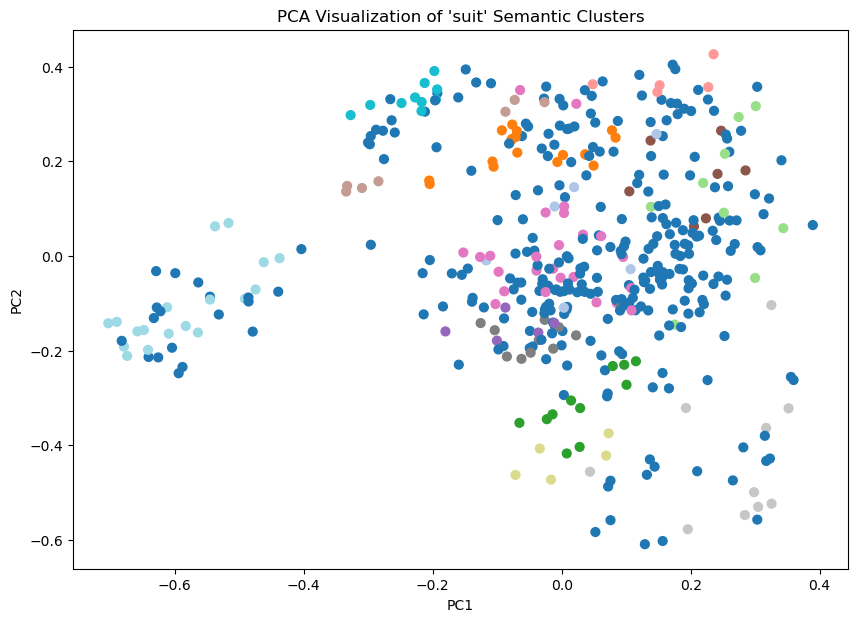

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
points_2d = pca.fit_transform(embeddings)
plt.figure(figsize=(10, 7))
plt.scatter(points_2d[:, 0], points_2d[:, 1], c=labels, cmap='tab20', s=40)
plt.title("PCA Visualization of 'suit' Semantic Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

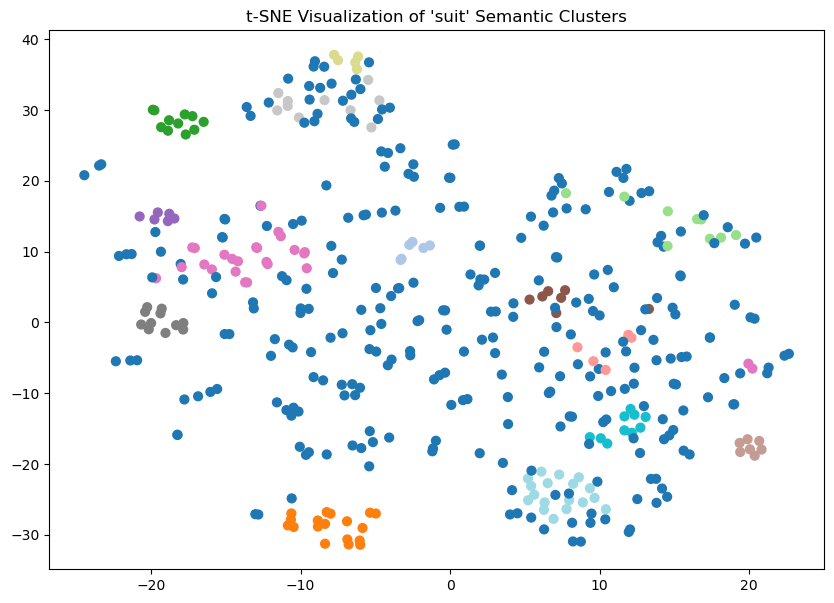

In [111]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random")
points_2d = tsne.fit_transform(embeddings)
plt.figure(figsize=(10,7))
plt.scatter(points_2d[:,0], points_2d[:,1], c=labels, cmap='tab20', s=40)
plt.title("t‑SNE Visualization of 'suit' Semantic Clusters")
plt.show()

In [14]:
[ df.filter(
    pl.col( 'os' ).is_not_null() &
    pl.col( col ).is_not_null()
).group_by( col ).agg(
  pl.col( 'os' )
    .n_unique( )
    .alias( f'{col}_os' ),
  pl.col( 'os' )
    .count( )
    .alias( f'{col}_exec' ),
  (
    pl.col( 'os' ).count( ) / pl.col( 'os' ).n_unique( )
  ).round( 2 ).alias( f'{col}_ratio' )
).sort( f'{col}_os', descending = True ) for col in [ 'un', 'group', 'field_location' ] ]

[shape: (10, 4)
 ┌──────────────────────┬───────┬─────────┬──────────┐
 │ un                   ┆ un_os ┆ un_exec ┆ un_ratio │
 │ ---                  ┆ ---   ┆ ---     ┆ ---      │
 │ cat                  ┆ u32   ┆ u32     ┆ f64      │
 ╞══════════════════════╪═══════╪═════════╪══════════╡
 │ UN-BC - SEDE  Bacia  ┆ 15053 ┆ 20428   ┆ 1.36     │
 │ UN-ES - SEDE  Espíri ┆ 7732  ┆ 10101   ┆ 1.31     │
 │ UN-BS -  EDISA II Sa ┆ 7239  ┆ 9299    ┆ 1.28     │
 │ BUZIOS/PRODUÇÃO - SE ┆ 3736  ┆ 4755    ┆ 1.27     │
 │ 2908                 ┆ 992   ┆ 1305    ┆ 1.32     │
 │ UN-RNCE  SEDE - Nata ┆ 312   ┆ 409     ┆ 1.31     │
 │ UN-SEAL  SEDE - Arm. ┆ 239   ┆ 353     ┆ 1.48     │
 │ UN-BA -  Salvador    ┆ 70    ┆ 128     ┆ 1.83     │
 │ E&P Corporativo      ┆ 6     ┆ 10      ┆ 1.67     │
 │ 2907                 ┆ 1     ┆ 1       ┆ 1.0      │
 └──────────────────────┴───────┴─────────┴──────────┘,
 shape: (30, 4)
 ┌───────┬──────────┬────────────┬─────────────┐
 │ group ┆ group_os ┆ group_exec ┆ gro

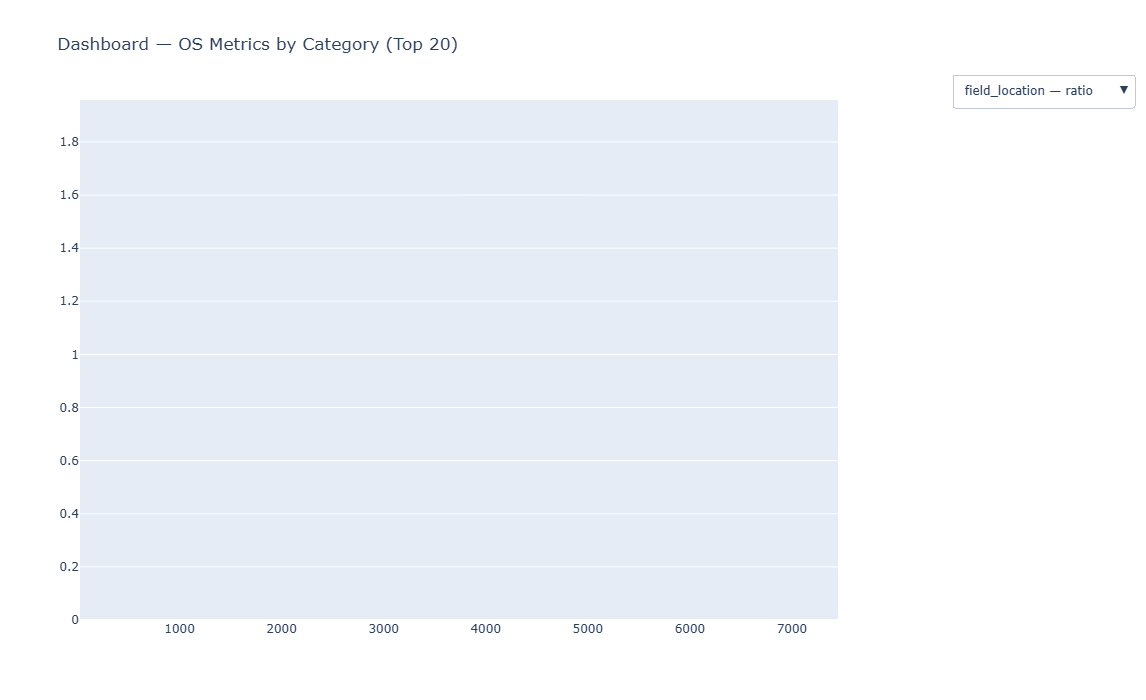

In [33]:
import plotly.graph_objects as go
import plotly.express as px
import polars as pl

# --- CONFIG ---
COLUMNS = ["un", "group", "field_location"]
TOP_N = 20

tabs = []  # will store all tab contents for the dashboard

for col in COLUMNS:
  # Compute metrics
    result = (
        df.filter(
            pl.col("os").is_not_null() &
            pl.col(col).is_not_null()
        )
        .group_by(col)
        .agg(
            pl.col("os").n_unique().alias(f"{col}_os"),
            pl.col("os").count().alias(f"{col}_exec"),
            (pl.col("os").count() / pl.col("os").n_unique())
                .round(2)
                .alias(f"{col}_ratio")
        )
        .sort(f"{col}_os", descending=True)
        .head(TOP_N)       # <--- LIMIT TO TOP 20
        .to_pandas()
    )
  # --- Grouped bar for OS + exec ---
    fig_counts = px.bar(
        result,
        x=col,
        y=[f"{col}_os", f"{col}_exec"],
        barmode="group",
        title=f"Top {TOP_N} — OS vs Executions by {col}",
        text_auto=True,
        height=600,
        width=1100
    )
    fig_counts.update_layout(xaxis_tickangle=45)
  # --- Ratio plot ---
    fig_ratio = px.bar(
        result,
        x=col,
        y=f"{col}_ratio",
        title=f"Top {TOP_N} — Ratio (exec / unique OS) by {col}",
        text_auto=True,
        height=500,
        width=900
    )
    fig_ratio.update_layout(xaxis_tickangle=45)
  # --- Add combined tab ---
    tabs.append(
        go.FigureWidget(fig_counts),  # main chart
    )
    tabs.append(
        go.FigureWidget(fig_ratio),   # ratio chart
    )


# --- Create Dashboard Layout ---
# Each column gets 2 charts → 6 total tabs
menu_buttons = []
for i, col in enumerate(COLUMNS):
    # counts chart index = 2*i
    # ratio chart index  = 2*i+1
  menu_buttons.append(
        dict(
            args=[{"visible": [j == 2*i     for j in range(6)]}],
            label=f"{col} — counts",
            method="update"
        )
    )
  menu_buttons.append(
        dict(
            args=[{"visible": [j == 2*i + 1 for j in range(6)]}],
            label=f"{col} — ratio",
            method="update"
        )
    )

# Combine all figures into one
dashboard = go.Figure()

# Add all traces into the figure (hidden by default except the first one)
for idx, fig in enumerate(tabs):
    for trace in fig.data:
        dashboard.add_trace(trace)
    # Set visibility
    for trace in dashboard.data:
        trace.visible = False
dashboard.data[0].visible = True  # show first tab

# Add dropdown menu
dashboard.update_layout(
    updatemenus=[
        dict(
            buttons=menu_buttons,
            direction="down",
            showactive=True,
            x=1.15,
            xanchor="left",
            y=1.05,
            yanchor="top"
        )
    ],
    title="Dashboard — OS Metrics by Category (Top 20)",
    height=700,
    width=1200
)

dashboard.show()

In [7]:
cm = df.group_by(
  ["un", "group"]
).agg(
  pl.col("os")
    .n_unique()
    .alias("os_count")
).pivot(
  index="un",
  on="group",
  values="os_count"
).fill_null(0)

In [7]:
rows = cm["un"].to_list()
cols = [c for c in cm.columns if c != "un"]

values = (
    cm.select(pl.all().exclude("un"))
      .fill_null(0)
      .cast(pl.Float64)
).to_numpy()

In [ ]:
rows = cm_sorted["un"].to_list()
cols = cm_sorted.columns[1:]

values = (
    cm_sorted.select(pl.all().exclude("un"))
             .fill_null(0)
             .with_columns(pl.all().replace("", "0"))
             .cast(pl.Float64)
).to_numpy()



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 12))

sns.heatmap(
    values,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=cols,
    yticklabels=rows,
    annot_kws={"size": 9}
)

plt.title("UN × Group – Unique OS Count")
plt.xlabel("Group")
plt.ylabel("UN")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [ ]:
%autoreload 2

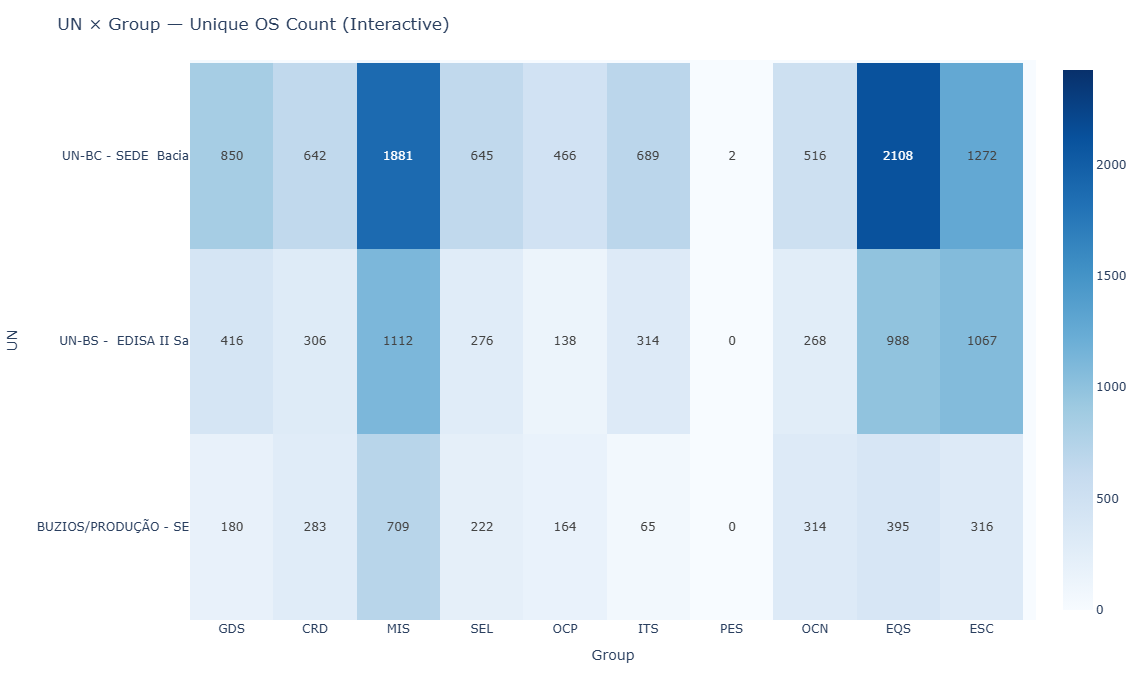

In [10]:
import plotly.express as px
import numpy as np
fig = px.imshow(
    values,
    x=cols,
    y=rows,
    color_continuous_scale="Blues",
    aspect="auto",
    text_auto=True,              # show numbers inside the matrix
)

fig.update_traces(
    hovertemplate=(
        "<b>UN:</b> %{y}<br>"
        "<b>Group:</b> %{x}<br>"
        "<b>OS Count:</b> %{z}<extra></extra>"
    )
)

fig.update_layout(
    title="UN × Group — Unique OS Count (Interactive)",
    xaxis_title="Group",
    yaxis_title="UN",
    width=1100,
    height=700
)

fig.show()

In [11]:
df.filter(
    pl.col("os").is_duplicated()
)

id,os,group,group_physical,group_count,desc,date,class,class_physical,class_count,un,un_physical,un_count,field_number,field_location,field_location_physical,field_location_count,depth,suit,suit_physical,suit_count,shipment,company,company_physical,company_count,resource,resource_physical,resource_count,vessel,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_physical,bucket_count,base,folder,path
i32,str,cat,u32,u32,str,date,cat,u32,u32,cat,u32,u32,i16,cat,u32,u32,i32,cat,u32,u32,str,cat,u32,u32,cat,u32,u32,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,u32,u32,str,str,str
112432,"""6000792398""","""ANC""",1,4367,"""Hook OUT linha #7 para estalei…",2025-11-26,"""Hook OUT""",0,105,"""UN-BC - SEDE Bacia""",2,20428,312,"""7-CG-5HP-RJS""",463,12,283,"""7-CG-5HP-RJS""",463,4,"""Abandonos 2022""","""C-Innovation""",403,8714,"""AHTS""",22,3727,"""Bram Titan""",6,228,"""BTCG26-004""",null,8,4.1596e9,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""sistemas-ancoragem""",27,4859,"""recursos-embarcacoes""","""OS006000792398""","""sistemas-ancoragem/recursos-em…"
112429,"""6000789371""","""MIS""",5,6571,"""Inspecao complementar em dutos…",2025-10-29,"""Inspeção complementar em dutos…",29,37,"""UN-ES - SEDE Espíri""",3,10101,881,"""P-52""",464,665,1770,"""Eor P-52""",1349,19,"""Eor ESDV-1 P-52""","""Oceânica""",405,5281,"""SDSV""",28,4015,"""Oceanica Subiv""",12,280,null,null,11,3.1623e9,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000789371-P-52-INSP-DUTO-…","""manutencao-inspecao-submarina/…"
112426,"""6000743153""","""CRD""",11,2914,"""Conexao submarina - tramo X eq…",2024-10-30,"""Conexão submarina - tramo X eq…",37,50,"""UN-BC - SEDE Bacia""",2,20428,682,"""7-MRL-183HP-RJS""",467,55,715,"""Po 7-MRL-183HP-RJS FPSO anita …",1351,5,"""7-MRL-183HP-RJS FPSO anita gar…","""Oceaneering""",406,1695,"""RSV""",35,25342,"""CBO Isabella""",16,704,"""CIMRL26-014""",null,15,1.3526e10,0,0.0,2026-01-13,2026-01-14,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000743153-CIMRL26-014""","""manutencao-inspecao-submarina/…"
112423,"""6000756132""","""MER""",8,7445,"""Med. de pot. eletroq. em dutos…",2025-02-07,"""Med. de pot. eletroq. em dutos""",44,152,"""UN-BC - SEDE Bacia""",2,20428,118,"""P-43""",469,861,800,"""2.4 atendimento AS RTI'S de du…",1354,213,"""P-43""","""Oceânica""",405,5281,"""SDSV""",28,4015,"""Oceanica Subiiv""",20,524,null,null,7,7.857078e6,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000756132-P-43-MPE-S-19-U…","""manutencao-inspecao-submarina/…"
112420,"""6000731362""","""MER""",8,7445,"""Insp final casco - acfm - boli…",2024-08-09,"""Insp final casco - acfm - boli…",48,53,"""UN-BC - SEDE Bacia""",2,20428,991,"""P-47""",471,283,197,"""P-47 / 2024""",1357,154,"""P-47 / 2024""","""Oceânica""",405,5281,"""SINS""",39,1720,"""Oceanica Subxviii""",24,332,"""VIIIVL26-005""",null,6,3.83388361e8,0,0.0,2026-01-13,2026-01-13,2026-01-14,2026-01-14,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS6000731362-SUBXVIIIVL26-005""","""manutencao-inspecao-submarina/…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4973,"""6000590795""","""EQS""",23,6769,"""Insp. dif. - med. de espes. 7-…",2021-01-05,"""Insp. dif. - med. de espes.""",177,122,"""UN-BC - SEDE Bacia""",2,20428,682,"""7-MRL-102H-RJS""",1053,64,880,"""Atp - MRL""",5108,6,"""Inspecoes (ICPI) UN-BC 2021""","""C-Innovation""",403,8714,"""RSV""",35,25342,"""Joe Griffin""",158,1077,"""JGMRL21-051""",null,15,1.1650e10,102,1.4563e10,2021-03-10,2024-09-12,2021-03-14,2024-09-15,2024-09-15,"""manutencao-inspe

In [12]:
df.select(
    pl.col("os")
).filter(
    pl.col("os").is_duplicated()
).unique()

os
str
"""6000698123"""
"""6000709847"""
"""6000675717"""
"""6000665271"""
"""6000707392"""
…
"""6000607275"""
"""6000738164"""
"""6000715067"""


In [47]:
df.select( 'suit' ).unique( )

suit
cat
"""P-54 - dutos"""
"""UDEH-OSS-03 X FPSO sepetiba"""
"""7-MLL-59D-RJS"""
"""MSP-MRL-1/P-35"""
"""7-MRO-33-RJS"""
"""7-BUZ-60D-RJS"""
"""RJS-34"""
"""Atp - MLL"""
"""Gl / 7-MRO-18D-RJS (LB2.P3)"""


In [36]:
#df.group_by("class").agg(
#    pl.len().alias("count"),
#    (pl.len() / df.height * 100).alias("pct")
#).sort("count", descending=True)

['group',
 'class',
 'un',
 'field_location',
 'suit',
 'company',
 'resource',
 'vessel',
 'bucket']

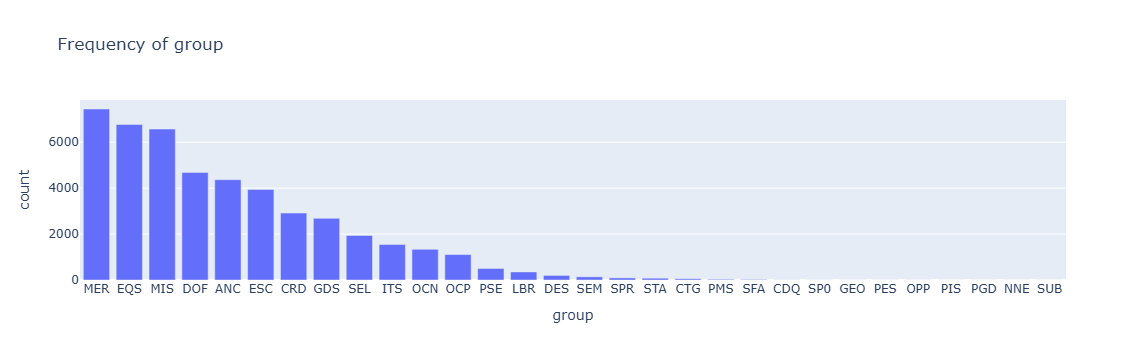

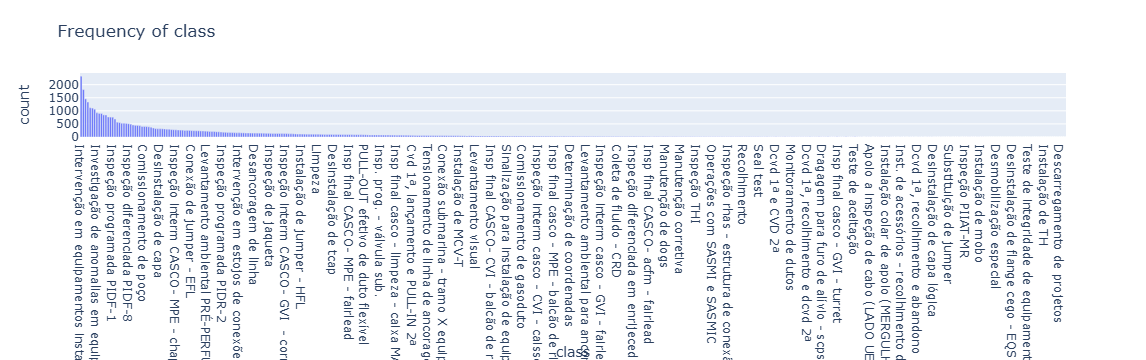

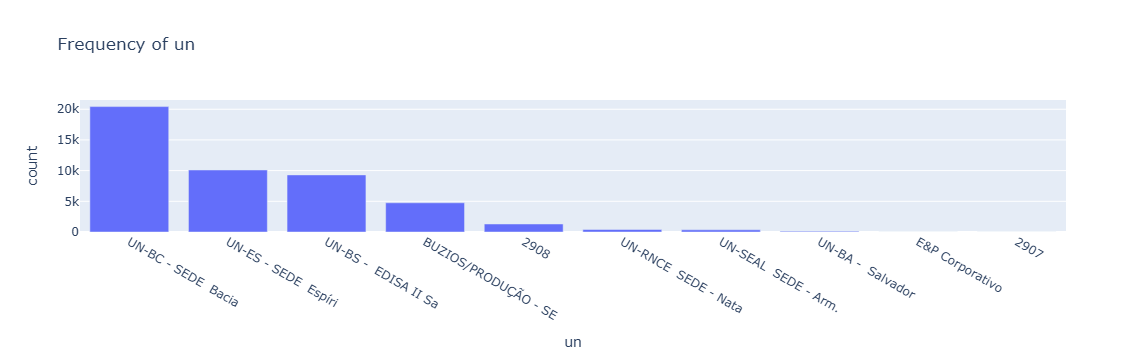

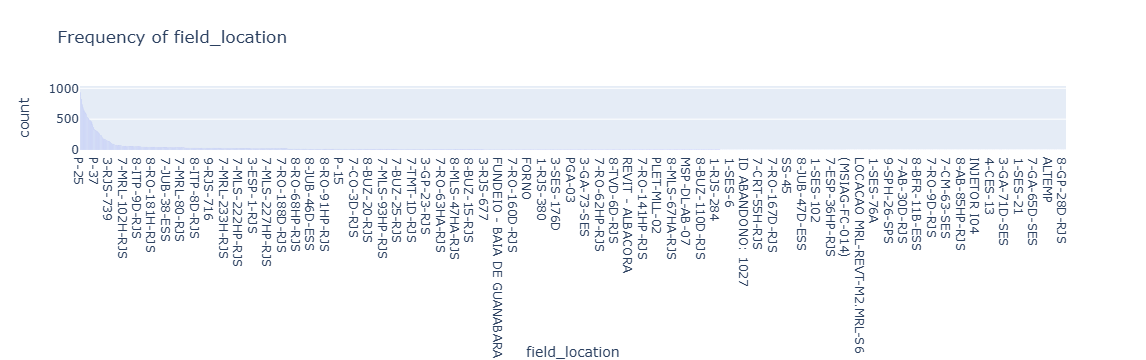

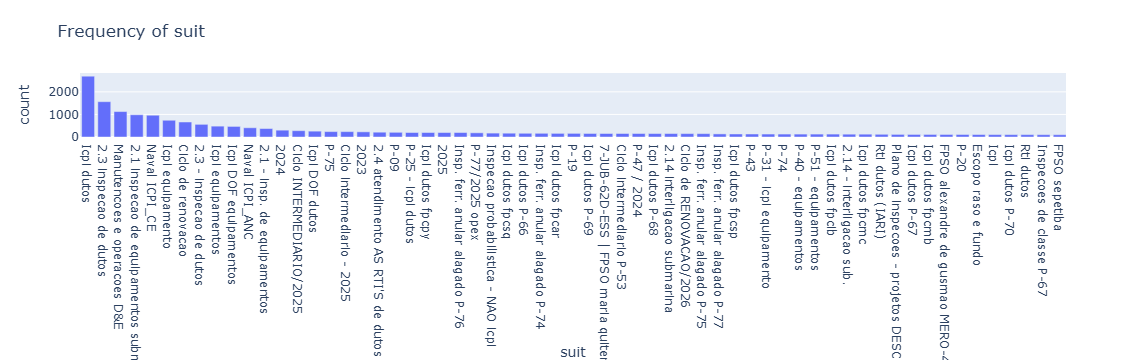

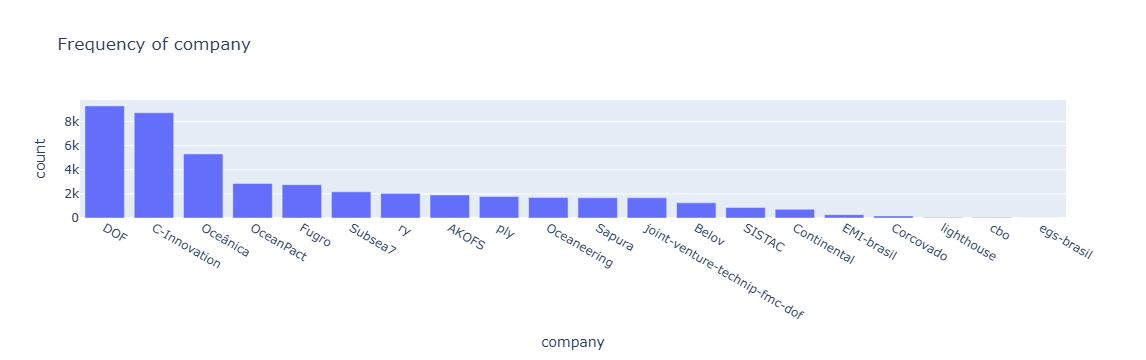

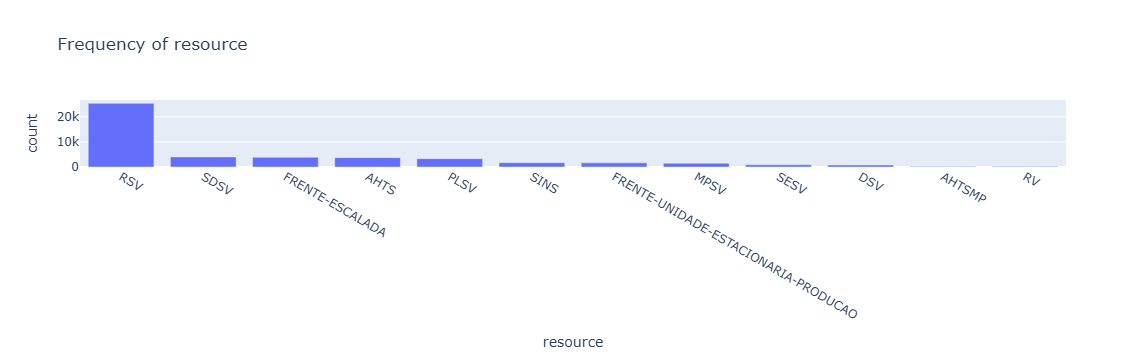

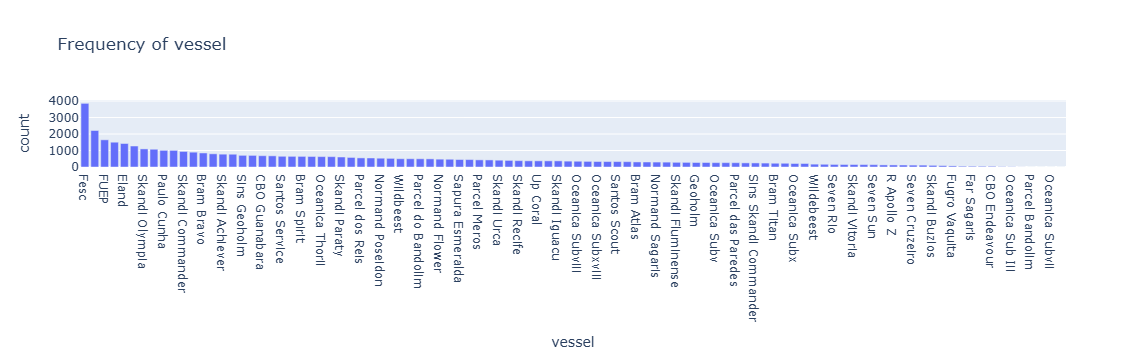

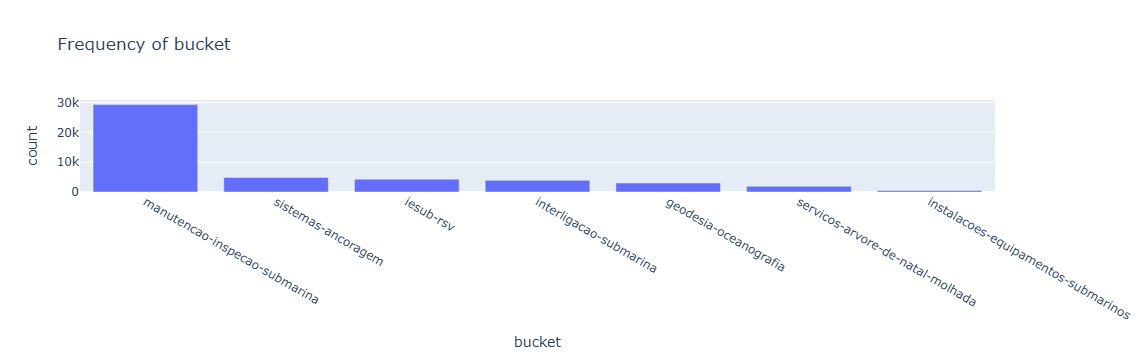

[None, None, None, None, None, None, None, None, None]

In [36]:
[ px.bar(
  (
    df.group_by(col)
      .agg(pl.len().alias("count"))
      .sort("count", descending=True)
      .to_pandas()
  ),
  x=col,
  y="count",
  title=f"Frequency of {col}"
).show( )
for col in df.select( cs.categorical( ) ).columns ]

In [38]:
df.select(pl.col("depth").max())

depth
i32
87693


In [39]:
df.select([
    pl.col("depth").min().alias("min_depth"),
    pl.col("depth").max().alias("max_depth"),
    pl.col("depth").mean().alias("mean_depth"),
    pl.col("depth").median().alias("median_depth")
])

min_depth,max_depth,mean_depth,median_depth
i32,i32,f64,f64
0,87693,1101.935049,1040.0


In [40]:
df.filter(pl.col("depth") == df.select(pl.col("depth").max()).item())

id,os,group,group_physical,group_count,desc,date,class,class_physical,class_count,un,un_physical,un_count,field_number,field_location,field_location_physical,field_location_count,depth,suit,suit_physical,suit_count,shipment,company,company_physical,company_count,resource,resource_physical,resource_count,vessel,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_physical,bucket_count,base,folder,path
i32,str,cat,u32,u32,str,date,cat,u32,u32,cat,u32,u32,i16,cat,u32,u32,i32,cat,u32,u32,str,cat,u32,u32,cat,u32,u32,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,u32,u32,str,str,str
102800,"""6000745191""","""MIS""",5,6571,"""Remocao de sucata (ID 8155) su…",2024-11-18,"""Remoção de sucata""",247,72,"""UN-BC - SEDE Bacia""",2,20428,118,"""CCBR10-119 13/10/2010 PDID A11""",1496,1,87693,"""Pdid A11""",2953,5,"""Pdid A-11""","""Oceânica""",405,5281,"""RSV""",35,25342,"""Oceanica Subviii""",15,349,null,null,43,3.8428e10,2,2.9578e9,2025-05-19,2025-05-27,2025-05-20,2025-05-28,2025-05-20,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000745191-SUB8BR25-045""","""manutencao-inspecao-submarina/…"


In [47]:
df.filter(
  pl.col( 'depth' ) >= df.select( pl.col( 'depth' ).quantile( 0.99 ) ).item( )
).sort( 'depth' )

id,os,group,group_physical,group_count,desc,date,class,class_physical,class_count,un,un_physical,un_count,field_number,field_location,field_location_physical,field_location_count,depth,suit,suit_physical,suit_count,shipment,company,company_physical,company_count,resource,resource_physical,resource_count,vessel,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_physical,bucket_count,base,folder,path
i32,str,cat,u32,u32,str,date,cat,u32,u32,cat,u32,u32,i16,cat,u32,u32,i32,cat,u32,u32,str,cat,u32,u32,cat,u32,u32,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,u32,u32,str,str,str
112219,"""6000747906""","""CRD""",11,2914,"""Intervencao em estojos de cone…",2024-12-09,"""Intervenção em estojos de cone…",49,160,"""UN-BS - EDISA II Sa""",4,9299,1104,"""P-70""",567,512,2300,"""INSPECAO/SUBTITUICAO de estojo…",1700,100,"""P-70 / 2024""","""Oceânica""",405,5281,"""RSV""",35,25342,"""Oceanica Subix""",142,500,null,null,295,2.1070e11,0,0.0,2026-01-07,2026-01-08,2026-01-08,2026-01-09,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000747906-SUB9ATP26-004""","""manutencao-inspecao-submarina/…"
112125,"""6000784756""","""EQS""",23,6769,"""Inspecao sem plano MSIAG-02 (M…",2025-09-22,"""Inspeção sem plano""",62,344,"""UN-BS - EDISA II Sa""",4,9299,1104,"""P-70""",567,512,2300,"""Icpi equipamentos P-70""",1728,74,"""P-70 / 2025""","""Sapura""",407,1676,"""PLSV""",56,3305,"""Sapura Onix""",117,120,"""SOATP25-042""",null,55,6.8923e10,0,0.0,2026-01-06,2026-01-06,2026-01-07,2026-01-07,null,"""interligacao-submarina""",65,3909,"""recursos-embarcacoes""","""006000784756-P-70""","""interligacao-submarina/recurso…"
112108,"""6000671766""","""MIS""",5,6571,"""Teste de integridade do anular…",2023-02-28,"""Teste de integridade do anular…",202,845,"""UN-BS - EDISA II Sa""",4,9299,1104,"""P-70""",567,512,2300,"""Insp. ferr. anular alagado (PI…",1737,64,"""P-70 / 2023""","""C-Innovation""",403,8714,"""RSV""",35,25342,"""Joe Griffin""",158,1077,"""JGATP26-002""",null,27,7.0993e9,0,0.0,2026-01-05,2026-01-05,2026-01-06,2026-01-06,null,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000671766-JGATP26-002""","""manutencao-inspecao-submarina/…"
111990,"""6000747793""","""CRD""",11,2914,"""Intervencao em estojos de cone…",2024-12-09,"""Intervenção em estojos de cone…",49,160,"""UN-BS - EDISA II Sa""",4,9299,1104,"""P-70""",567,512,2300,"""INSPECAO/SUBTITUICAO de estojo…",1700,100,"""P-70 / 2024""","""Oceânica""",405,5281,"""RSV""",35,25342,"""Oceanica Subix""",142,500,null,null,267,1.8970e11,3,1.4076e9,2026-01-02,2026-01-07,2026-01-03,2026-01-08,2026-01-07,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000747793-SUB9ATP26-001""","""manutencao-inspecao-submarina/…"
111786,"""6000747908""","""CRD""",11,2914,"""Intervencao em estojos de cone…",2024-12-09,"""Intervenção em estojos de cone…",49,160,"""UN-BS - EDISA II Sa""",4,9299,1104,"""P-70""",567,512,2300,"""INSPECAO/SUBTITUICAO de estojo…",1700,100,"""P-70 / 2024""","""C-Innovation""",403,8714,"""RSV""",35,25342,"""Normand Poseidon""",113,533,"""NPATP25-139""",null,151,6.7667e10,7,5.2138e9,2025-12-28,2026-01-02,2025-12-29,2026-01-03,2025-12-31,"""manutencao-inspecao-submarina""",45,29290,"""recursos-embarcacoes""","""OS006000747908-NPATP25-139""","""manutencao-inspecao-submarina/…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
70192,"""6000678225""","""GDS""",26,2684,"""Levantamento ambiental PRE-PER…",2023-04-27,"""Levantamento ambiental PRÉ-PER…",169,220,"""UN-ES - SEDE Espíri""",3,10101,0,"""FUJI""",3518,2,2850,"""Fuji (BLOCO ES-M-673)""",4733,2,"""Fuji (BLOCO ES-M-673)""","""Fugro""",null,0,"""RSV""",35,25342,"""Up Coral""",1347,373,"""UCout23-043""",null,248,1.6303e11,41,6.2415189e7,2023-08-18,2